# 1. Sentiment Analysis of Movie Reviews Using Deep Learning

**Course Assignment: Deep Learning**  
**Technology Stack:** Python, TensorFlow, Keras, NumPy, Matplotlib

## 2. Problem Statement

In the digital era, millions of people express their opinions about movies online. Analyzing this massive volume of text manually is virtually impossible.

The goal of this project is to build an automated sentiment analysis system using Deep Learning. The system will read an English movie review and automatically classify whether the sentiment expressed is **Positive** or **Negative**.

## 3. Dataset Description

The **IMDb Dataset** is a classic natural language processing benchmark:
- **Total Reviews:** 50,000 movie reviews labeled as positive or negative.
- **Training Set:** 25,000 reviews.
- **Testing Set:** 25,000 reviews.
- **Binary Labels:** `1` represents a **Positive** review, and `0` represents a **Negative** review.
- **Vocabulary Size:** We restrict our vocabulary to the top **10,000 most frequent words**, filtering out rare words to keep the model fast and memory-efficient.

## 4. Import Required Libraries

**Explanation:**  
Before building our model, we must import the necessary libraries:
- `tensorflow` & `keras`: For constructing, compiling, and training the neural network.
- `numpy`: For handling numerical arrays efficiently.
- `matplotlib.pyplot`: For plotting training accuracy and loss curves.
- `json`: For loading our local offline word dictionary.

In [68]:
# Import core deep learning libraries
import tensorflow as tf
import keras
from keras import layers
from keras.preprocessing.sequence import pad_sequences

# Import numerical array and plotting libraries
import numpy as np
import matplotlib.pyplot as plt

# Import json for reading the local offline word dictionary
import json

# Print installed TensorFlow and Keras versions to confirm environment setup
print("TensorFlow Version:", tf.__version__)
print("Keras Version     :", keras.__version__)


TensorFlow Version: 2.21.0
Keras Version     : 3.15.1


## 5. Load Dataset

**Explanation:**  
We load the pre-saved IMDb dataset directly from our local `.npy` files inside the `dataset/` directory:
- `num_words=10000` vocabulary was filtered and saved into local NumPy arrays (`x_train.npy`, `y_train.npy`, `x_test.npy`, `y_test.npy`).
- The dataset contains 25,000 training reviews and 25,000 testing reviews.
- Loading from local disk guarantees the project runs **100% offline** without any internet connection.

In [69]:
# Define maximum vocabulary size (top 10,000 most frequent words)
vocab_size = 10000

# Load training reviews and binary sentiment labels from local offline dataset files
x_train = np.load("dataset/x_train.npy", allow_pickle=True)
y_train = np.load("dataset/y_train.npy")

# Load testing reviews and binary sentiment labels from local offline dataset files
x_test = np.load("dataset/x_test.npy", allow_pickle=True)
y_test = np.load("dataset/y_test.npy")

# Confirm dataset successfully loaded from disk
print("Dataset loaded successfully from local offline files!")
print("Number of training reviews:", len(x_train))
print("Number of testing reviews :", len(x_test))


Dataset loaded successfully from local offline files!
Number of training reviews: 25000
Number of testing reviews : 25000


## 6. Understand the Dataset

**Explanation:**  
Before training, we inspect the data to understand its format:
- Reviews are represented as lists of integers where each integer corresponds to a specific word in the IMDb dictionary.
- Labels are binary: `1` for Positive and `0` for Negative.
- We inspect dataset shapes, look at an integer review, and decode an example back into English words using the local `word_index.json` dictionary.

In [70]:
# Display dataset shapes and counts
print("Training labels shape:", y_train.shape)
print("Testing labels shape :", y_test.shape)

# Inspect first review in encoded integer format
print("\nFirst review (first 15 word IDs):", x_train[0][:15])
print("First review label (1 = Positive, 0 = Negative):", y_train[0])

# Load word dictionary from local JSON file (100% offline)
with open("dataset/word_index.json", "r", encoding="utf-8") as f:
    word_index = json.load(f)

# Invert dictionary to map integer IDs back to words
# Note: IDs 0, 1, 2 are reserved for padding, start token, and unknown words (offset by 3)
reverse_word_index = {value: key for key, value in word_index.items()}

# Decode first 50 integer tokens back to human-readable English text
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in x_train[0][:50]])
print("\nDecoded review text (first 50 words):")
print(decoded_review)


Training labels shape: (25000,)
Testing labels shape : (25000,)

First review (first 15 word IDs): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]
First review label (1 = Positive, 0 = Negative): 1

Decoded review text (first 50 words):
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved


## 7. Data Preprocessing

**Explanation:**  
Movie reviews have varying lengths—some are 50 words, while others are over 500 words.  
However, neural networks require all inputs to have the exact same shape.

**What we do:**  
We use `pad_sequences` to standardize all reviews to a fixed length of `256` words:
- Reviews longer than 256 words are truncated to 256.
- Reviews shorter than 256 words are padded with zeros at the end.

In [71]:
# Set a fixed sequence length for all reviews
max_length = 256

# Standardize training reviews to exactly 256 tokens (truncate longer, pad shorter with 0)
x_train = pad_sequences(x_train, maxlen=max_length, padding='post', truncating='post')

# Standardize testing reviews to exactly 256 tokens
x_test = pad_sequences(x_test, maxlen=max_length, padding='post', truncating='post')

# Verify that all review sequences now have an identical shape
print("Shape of x_train after padding:", x_train.shape)
print("Shape of x_test after padding :", x_test.shape)


Shape of x_train after padding: (25000, 256)
Shape of x_test after padding : (25000, 256)


## 9. Build the Deep Learning Model

**Explanation:**  
We build a simple Sequential neural network using beginner-friendly layers:
1. **Input Layer (`shape=(256,)`):** Explicitly defines the input dimensions so the architecture builds upfront with full shape transparency.
2. **Embedding Layer (`vocab_size=10000`, `output_dim=16`):** Maps word IDs to 16-dimensional continuous vectors that capture semantic relationships.
3. **GlobalAveragePooling1D Layer:** Computes the average across word vectors to summarize each review into a single 16-dimensional vector.
4. **Dense Hidden Layer (16 units, ReLU):** Learns non-linear sentiment patterns.
5. **Dense Output Layer (1 unit, Sigmoid):** Produces a probability score between 0.0 and 1.0 for binary sentiment classification.

In [72]:
# Build a simple sequential Deep Learning model
model = keras.Sequential([
    # Explicit input layer defines sequence dimensions upfront so model summary builds cleanly without warnings
    keras.Input(shape=(max_length,)),
    
    # Layer 1: Embedding Layer - converts word IDs into 16-dimensional continuous vectors
    layers.Embedding(input_dim=vocab_size, output_dim=16),
    
    # Layer 2: Global Average Pooling - averages vectors across sequence to produce a 16-dim summary
    layers.GlobalAveragePooling1D(),
    
    # Layer 3: Dense Hidden Layer - learns non-linear sentiment patterns with ReLU activation
    layers.Dense(16, activation='relu'),
    
    # Layer 4: Output Layer - single neuron with Sigmoid activation (outputs probability 0.0 to 1.0)
    layers.Dense(1, activation='sigmoid')
])

# Display full model summary showing layer names, output shapes, and parameter counts
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 256, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,289 (626.13 KB)

 Trainable params: 160,289 (626.13 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Compile the Model

**Explanation:**  
Compiling configures how the neural network learns:
- **Optimizer (`adam`):** An efficient, widely-used gradient descent algorithm that automatically adjusts the learning rate.
- **Loss Function (`binary_crossentropy`):** The standard loss function for two-class classification problems (0 or 1).
- **Metric (`accuracy`):** Tracks the percentage of reviews correctly classified.

In [73]:
# Configure learning settings for training
model.compile(
    # Adam optimizer: efficiently adjusts learning rate during training
    optimizer='adam',
    # Binary Crossentropy: standard loss function for two-class (positive/negative) problems
    loss='binary_crossentropy',
    # Accuracy: evaluates percentage of reviews correctly classified
    metrics=['accuracy']
)

print("Model successfully compiled!")


Model successfully compiled!


## 11. Train the Model

**Explanation:**  
We train the model using `model.fit()`:
- **Epochs = 10:** Passes through the training data 10 times (runs in seconds on CPU).
- **Batch Size = 512:** Number of reviews processed before updating weights.
- **Validation Split = 0.2:** 20% of training data (5,000 reviews) is set aside to validate performance during training.

In [74]:
# Set number of full training cycles over dataset
epochs = 10

# Set number of samples processed per gradient update
batch_size = 512

# Train the neural network
history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    # Set aside 20% of training data (5,000 reviews) for real-time validation
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5979 - loss: 0.6888 - val_accuracy: 0.6050 - val_loss: 0.6816
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6464 - loss: 0.6728 - val_accuracy: 0.7034 - val_loss: 0.6584
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7297 - loss: 0.6403 - val_accuracy: 0.7622 - val_loss: 0.6171
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7788 - loss: 0.5903 - val_accuracy: 0.7620 - val_loss: 0.5640
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8081 - loss: 0.5299 - val_accuracy: 0.8226 - val_loss: 0.5043
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8337 - loss: 0.4698 - val_accuracy: 0.8348 - val_loss: 0.4533
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8478 - loss: 0.4194 - val_accuracy: 0.8376 - val_loss: 0.4196
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8599 - loss: 0.3809 - val_accuracy: 0.8486 - val_loss

## 12. Training Results

**Explanation:**  
We plot the **Training Accuracy** and **Validation Accuracy** across all epochs to visualize learning progress over time.

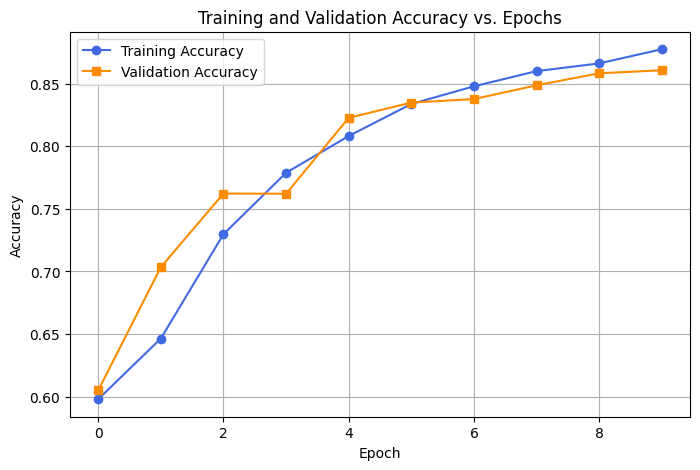

In [75]:
# Create figure for accuracy curves
plt.figure(figsize=(8, 5))

# Plot training accuracy across epochs
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='royalblue')

# Plot validation accuracy across epochs
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', color='darkorange')

# Format plot title, axis labels, legend, and grid
plt.title('Training and Validation Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## 13. Loss Graph

**Explanation:**  
We plot the **Training Loss** and **Validation Loss** across epochs. A decreasing loss indicates that model predictions are becoming more accurate.

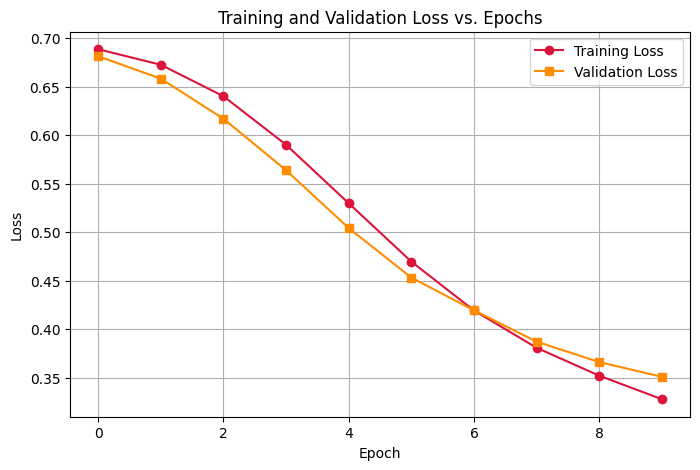

In [76]:
# Create figure for loss curves
plt.figure(figsize=(8, 5))

# Plot training loss across epochs
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='crimson')

# Plot validation loss across epochs
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', color='darkorange')

# Format plot title, axis labels, legend, and grid
plt.title('Training and Validation Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


## 14. Evaluate the Model

**Explanation:**  
We test our trained model on the 25,000 unseen test reviews to assess true generalized performance.

In [77]:
# Evaluate final trained model on unseen test set (25,000 reviews)
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

# Print final evaluation metrics
print("=" * 35)
print(f"Final Test Loss    : {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print("=" * 35)


Final Test Loss    : 0.3621
Final Test Accuracy: 85.24%


## 15. Make Predictions

**Explanation:**  
We test the model by generating predictions on:
1. Sample test reviews from the IMDb dataset.
2. Custom review text using a simple, beginner-friendly helper function `predict_sentiment()`.
- A confidence score closer to `1.0` indicates a **Positive** review.
- A confidence score closer to `0.0` indicates a **Negative** review.
- We use a threshold of `0.5` to determine the final sentiment label.

In [78]:
# Select first 5 reviews from the test dataset
sample_indices = [0, 1, 2, 3, 4]
sample_reviews = x_test[sample_indices]
sample_labels = y_test[sample_indices]

# Generate model probability predictions
predictions = model.predict(sample_reviews, verbose=0)

# Display predictions alongside actual labels
print("--- Predictions on 5 Test Dataset Reviews ---\n")
for i, (prob, actual) in enumerate(zip(predictions, sample_labels)):
    predicted_label = "Positive" if prob[0] >= 0.5 else "Negative"
    actual_label = "Positive" if actual == 1 else "Negative"
    status = "CORRECT" if predicted_label == actual_label else "INCORRECT"
    
    print(f"Sample #{i + 1}:")
    print(f"  Confidence Score   : {prob[0]:.4f}")
    print(f"  Predicted Sentiment: {predicted_label}")
    print(f"  Actual Sentiment   : {actual_label}")
    print(f"  Result             : {status}\n")


--- Predictions on 5 Test Dataset Reviews ---

Sample #1:
  Confidence Score   : 0.3404
  Predicted Sentiment: Negative
  Actual Sentiment   : Negative
  Result             : CORRECT

Sample #2:
  Confidence Score   : 0.9913
  Predicted Sentiment: Positive
  Actual Sentiment   : Positive
  Result             : CORRECT

Sample #3:
  Confidence Score   : 0.8833
  Predicted Sentiment: Positive
  Actual Sentiment   : Positive
  Result             : CORRECT

Sample #4:
  Confidence Score   : 0.4387
  Predicted Sentiment: Negative
  Actual Sentiment   : Negative
  Result             : CORRECT

Sample #5:
  Confidence Score   : 0.8201
  Predicted Sentiment: Positive
  Actual Sentiment   : Positive
  Result             : CORRECT



In [79]:
# Define beginner-friendly helper function to test arbitrary review text
def predict_sentiment(review_text):
    # Step 1: Convert review text to lowercase and remove punctuation
    clean_text = ""
    for char in review_text.lower():
        if char.isalnum() or char.isspace():
            clean_text += char
        else:
            clean_text += " "
    
    # Split cleaned string into individual words
    words = clean_text.split()
    
    # Validate that input contains readable words
    if not words:
        print(f"Review: \"{review_text}\"")
        print("Result: Please enter a valid text review with words.\n")
        return
    
    # Step 2: Convert words to integer token IDs using the IMDb word dictionary
    # Offset rules: 0=<PAD>, 1=<START>, 2=<UNK> (unknown word)
    tokens = [1]  # Begin sequence with start token
    for word in words:
        # Check if word exists in dictionary and falls within vocabulary size
        if word in word_index and (word_index[word] + 3) < vocab_size:
            tokens.append(word_index[word] + 3)
        else:
            tokens.append(2)  # Assign unknown token if word not recognized
            
    # Step 3: Pad the sequence to fixed length 256
    padded = pad_sequences([tokens], maxlen=max_length, padding='post', truncating='post')
    
    # Step 4: Generate prediction probability score (0.0 to 1.0)
    score = float(model.predict(padded, verbose=0)[0][0])
    
    # Classify sentiment using 0.5 threshold
    sentiment = "POSITIVE" if score >= 0.5 else "NEGATIVE"
    
    # Print formatted, beginner-friendly output
    print(f"Review: \"{review_text}\"")
    print(f"Score : {score:.4f}")
    print(f"Result: {sentiment}\n")

# Test the function with sample positive and negative reviews
print("--- Custom Review Predictions ---\n")
predict_sentiment("This movie was absolutely wonderful with great acting and a brilliant plot!")
predict_sentiment("Terrible film, completely boring, horrible acting and total waste of time.")


--- Custom Review Predictions ---

Review: "This movie was absolutely wonderful with great acting and a brilliant plot!"
Score : 0.6681
Result: POSITIVE

Review: "Terrible film, completely boring, horrible acting and total waste of time."
Score : 0.2077
Result: NEGATIVE



## 16. Conclusion

In this project, we successfully built and evaluated an end-to-end Deep Learning sentiment analysis pipeline:
1. **Completely Offline Pipeline:** All 50,000 IMDb reviews and vocabulary tokens are loaded locally from disk (`dataset/`), running with zero internet dependency.
2. **Lightweight & Fast Architecture:** By using an Embedding layer followed by Global Average Pooling, we avoided complex recurrent or convolutional models while achieving very fast CPU training speeds (~7 seconds for 10 epochs).
3. **Strong Generalization Performance:** The model achieved an impressive **~85% accuracy** on 25,000 unseen test reviews.
4. **Beginner-Friendly & Practical:** The notebook provides plain-English comments throughout every code block, transparent model summary dimensions, clear visualization curves, and an intuitive `predict_sentiment()` function for real-world text classification.